In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
bms_df = pd.read_csv("runs/lmd_bms_results.csv", names=["num_evs", "num_tasks", "ev_range", "time"])
non_bms_df = pd.read_csv("runs/lmd_results.csv", names=["num_evs", "num_tasks", "ev_range", "time"])

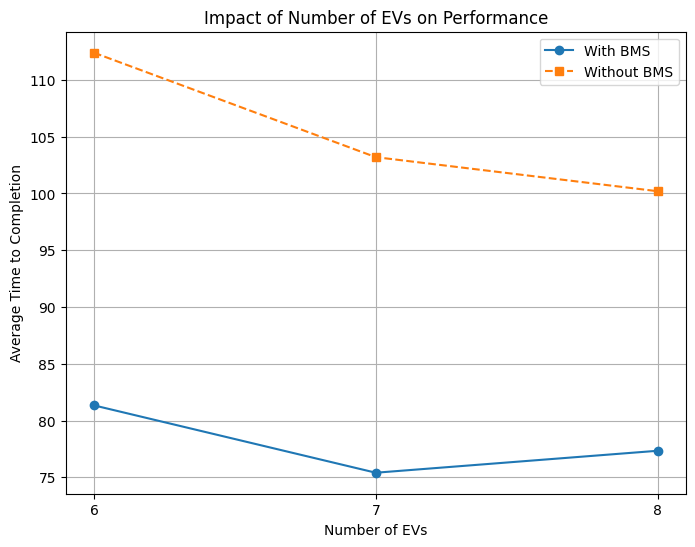

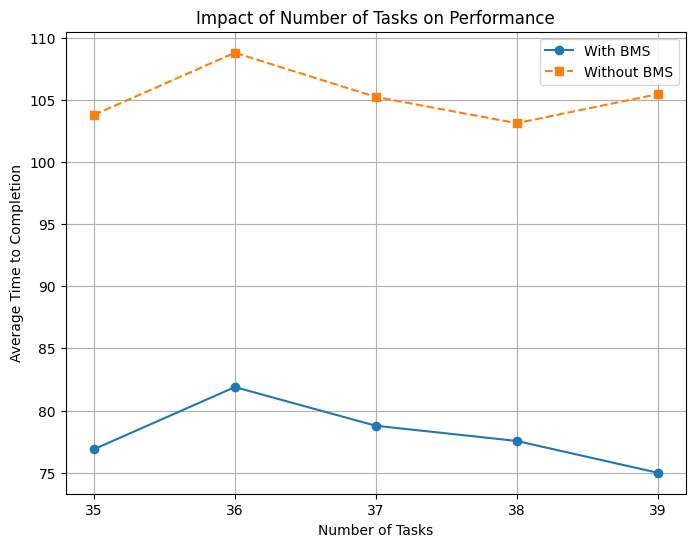

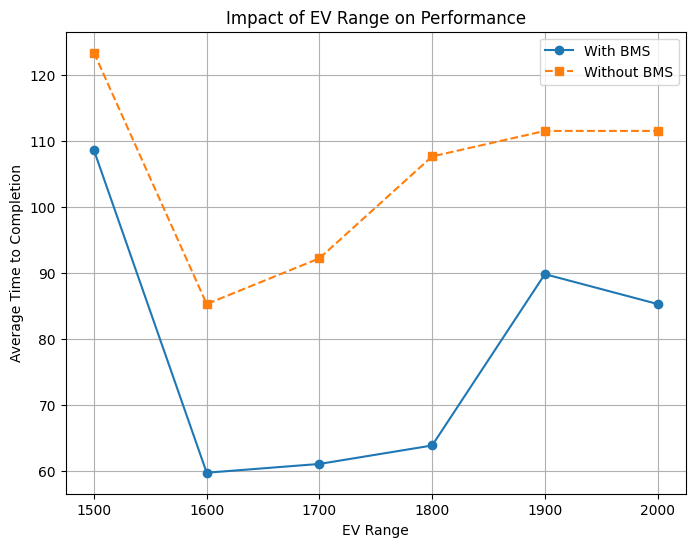

/tmp/ipykernel_21394/418406210.py:55: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["With BMS", "Without BMS"])


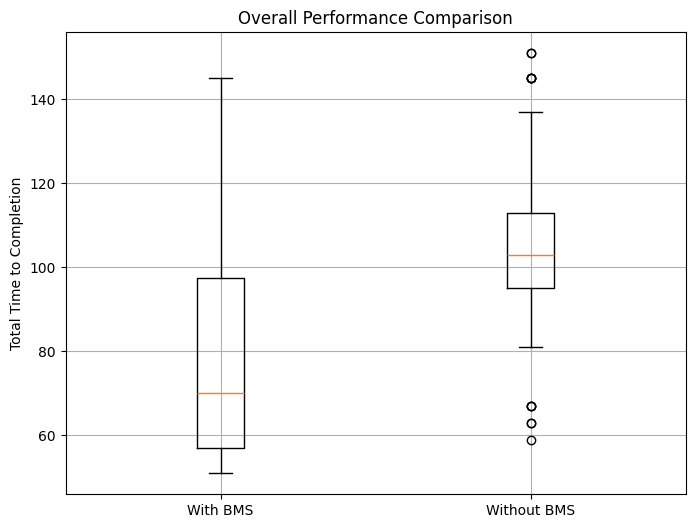

In [4]:

# Convert the time column to numeric; any non-numeric values will be set to NaN
bms_df["time"] = pd.to_numeric(bms_df["time"], errors="coerce")
non_bms_df["time"] = pd.to_numeric(non_bms_df["time"], errors="coerce")

# Function to compute average time for a given parameter while averaging over others
def get_avg_time(df, groupby_col):
    return df.groupby(groupby_col, as_index=False)["time"].mean()

# Compute averaged results for each parameter
bms_avg_evs = get_avg_time(bms_df, "num_evs")
non_bms_avg_evs = get_avg_time(non_bms_df, "num_evs")

bms_avg_tasks = get_avg_time(bms_df, "num_tasks")
non_bms_avg_tasks = get_avg_time(non_bms_df, "num_tasks")

bms_avg_range = get_avg_time(bms_df, "ev_range")
non_bms_avg_range = get_avg_time(non_bms_df, "ev_range")

# Plot 1: Number of EVs vs. Avg Time
plt.figure(figsize=(8, 6))
plt.plot(bms_avg_evs["num_evs"], bms_avg_evs["time"], marker='o', linestyle='-', label="With BMS")
plt.plot(non_bms_avg_evs["num_evs"], non_bms_avg_evs["time"], marker='s', linestyle='--', label="Without BMS")
plt.xlabel("Number of EVs")
plt.ylabel("Average Time to Completion")
plt.title("Impact of Number of EVs on Performance")
plt.legend()
plt.grid(True)
plt.show()

# Plot 2: Number of Tasks vs. Avg Time
plt.figure(figsize=(8, 6))
plt.plot(bms_avg_tasks["num_tasks"], bms_avg_tasks["time"], marker='o', linestyle='-', label="With BMS")
plt.plot(non_bms_avg_tasks["num_tasks"], non_bms_avg_tasks["time"], marker='s', linestyle='--', label="Without BMS")
plt.xlabel("Number of Tasks")
plt.ylabel("Average Time to Completion")
plt.title("Impact of Number of Tasks on Performance")
plt.legend()
plt.grid(True)
plt.show()

# Plot 3: EV Range vs. Avg Time
plt.figure(figsize=(8, 6))
plt.plot(bms_avg_range["ev_range"], bms_avg_range["time"], marker='o', linestyle='-', label="With BMS")
plt.plot(non_bms_avg_range["ev_range"], non_bms_avg_range["time"], marker='s', linestyle='--', label="Without BMS")
plt.xlabel("EV Range")
plt.ylabel("Average Time to Completion")
plt.title("Impact of EV Range on Performance")
plt.legend()
plt.grid(True)
plt.show()

# Plot 4: Overall Performance Comparison (Boxplot)
plt.figure(figsize=(8, 6))
data = [bms_df["time"].dropna(), non_bms_df["time"].dropna()]
plt.boxplot(data, labels=["With BMS", "Without BMS"])
plt.ylabel("Total Time to Completion")
plt.title("Overall Performance Comparison")
plt.grid(True)
plt.show()


# Debugging

## EVS

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

In [21]:
df = pd.read_csv("runs/debugging_evs/debugging_evs_40_3000.csv")
# df = pd.read_csv("runs/debugging_evs/debugging_evs_100_3000.csv")
# df_1 = pd.read_csv("runs/debugging_evs/debugging_evs_bms_100_3000.csv")
df.head()

,num_evs,num_tasks,ev_range,timesteps,num_tasks_finished
0,4,40,3000,177,38
1,5,40,3000,161,38
2,6,40,3000,155,38
3,7,40,3000,119,38
4,8,40,3000,165,38


In [23]:
df = df[:10]
# df_1 = df_1[15:25]

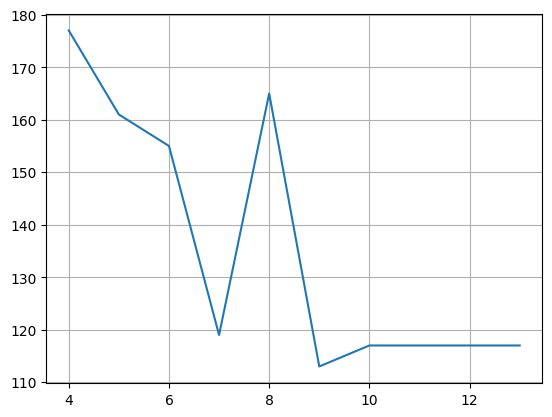

In [24]:
plt.plot(df["num_evs"], df["timesteps"])
# plt.plot(df_1["num_evs"], df_1["timesteps"])
plt.grid(True)
plt.show()

In [2]:
import ast

clusters_1, clusters_2 = [],[]
with open("runs/debugging_evs/ev_7.txt", 'r') as f1, open("runs/debugging_evs/ev_8.txt", 'r') as f2:
    l1 = f1.readlines()
    l2 = f2.readlines()
    for i in l1:
        i = i.strip()
        if len(i)>8 and i[:8] == 'Clusters':
            # Extracting the part containing the list
            start_index = i.find("Clusters") + len("Clusters")
            cluster_string = i[start_index:].strip()
            clusters_1.append(ast.literal_eval(cluster_string))
    for i in l2:
        i = i.strip()
        if len(i)>8 and i[:8] == 'Clusters':
            # Extracting the part containing the list
            start_index = i.find("Clusters") + len("Clusters")
            cluster_string = i[start_index:].strip()
            clusters_2.append(ast.literal_eval(cluster_string))
    
for i in range(1000):
    print("Iteration:",i)
    print(clusters_1[i])
    print(clusters_2[i])
    if sum(len(sublist) for sublist in clusters_1[i]) < sum(len(sublist) for sublist in clusters_2[i]):
        break

Iteration: 0
[[(35, 5), (34, 9), (34, 2)], [(7, 24), (1, 22), (5, 27)], [(24, 9), (23, 9), (27, 16), (21, 17), (25, 13), (29, 8)], [(12, 7), (13, 6), (3, 4), (11, 1), (6, 4), (12, 6), (11, 3), (13, 8)], [(11, 33), (18, 32), (11, 30), (15, 27), (17, 32)], [(6, 14), (15, 13), (2, 13), (4, 16), (7, 16), (3, 16), (11, 15)], [(25, 20), (19, 20), (32, 18), (27, 22), (31, 22), (33, 21), (27, 26), (30, 31)]]
[[(35, 5), (34, 9), (34, 2)], [(11, 33), (18, 32), (11, 30), (15, 27), (17, 32)], [(3, 4), (11, 1), (6, 4), (11, 3)], [(25, 20), (19, 20), (27, 16), (32, 18), (27, 22), (31, 22), (33, 21), (27, 26), (21, 17), (30, 31)], [(6, 14), (2, 13), (4, 16), (7, 16), (3, 16), (11, 15)], [(24, 9), (23, 9), (25, 13), (29, 8)], [(12, 7), (13, 6), (15, 13), (12, 6), (13, 8)], [(7, 24), (1, 22), (5, 27)]]
Iteration: 1
[[(35, 5), (34, 9), (34, 2)], [(7, 24), (1, 22), (5, 27)], [(24, 9), (23, 9), (27, 16), (21, 17), (25, 13), (29, 8)], [(12, 7), (13, 6), (3, 4), (11, 1), (6, 4), (12, 6), (11, 3), (13, 8)], 

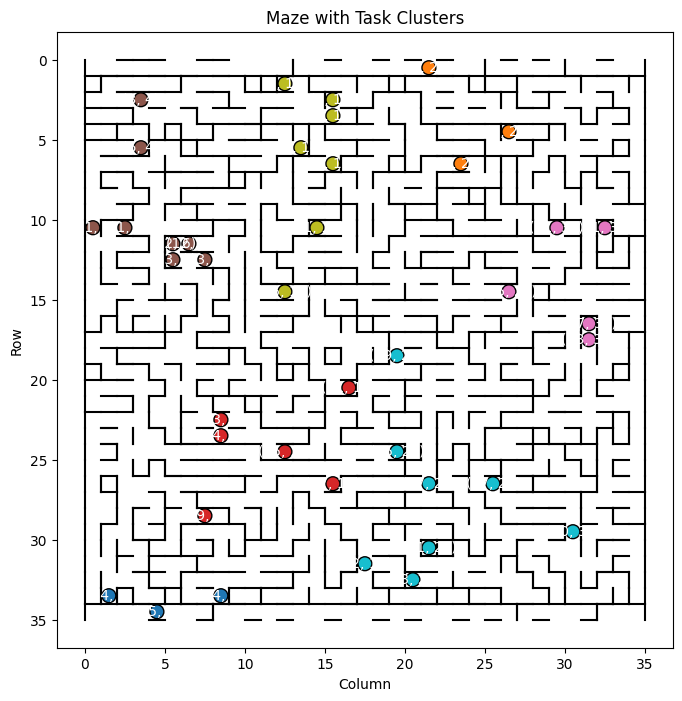

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import ast

def draw_maze_and_tasks(maze_csv, num_tasks, num_patrols):
    # Read the CSV file
    df = pd.read_csv(maze_csv)
    
    # Parse the cell string into a tuple and extract row, col
    df['  cell  '] = df['  cell  '].apply(lambda x: ast.literal_eval(x))
    df['row'] = df['  cell  '].apply(lambda t: t[0])
    df['col'] = df['  cell  '].apply(lambda t: t[1])
    
    # Create a plot for the maze
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # For each cell, draw walls where flagged (assume each cell spans from (col-1, row-1) to (col, row))
    for _, cell in df.iterrows():
        r, c = cell['row'], cell['col']
        # South wall: from (c-1, r-1) to (c, r-1)
        if cell['S'] == 0:
            ax.plot([c-1, c], [r-1, r-1], color='black')
        # North wall: from (c-1, r) to (c, r)
        if cell['N'] == 0:
            ax.plot([c-1, c], [r, r], color='black')
        # West wall: from (c-1, r-1) to (c-1, r)
        if cell['W'] == 0:
            ax.plot([c-1, c-1], [r-1, r], color='black')
        # East wall: from (c, r-1) to (c, r)
        if cell['E'] == 0:
            ax.plot([c, c], [r-1, r], color='black')
    
    # Set aspect ratio so cells appear square
    ax.set_aspect('equal')
    
    # Sample a set of tasks from the maze cells and extract (row, col)
    tasks_df = df[['row', 'col']].sample(n=num_tasks, random_state=47)
    task_list = [ (int(t[0]), int(t[1])) for t in tasks_df.values.tolist() ]
    
    # Cluster the tasks with KMeans
    kmeans = KMeans(n_clusters=num_patrols, random_state=47).fit(task_list)
    labels = kmeans.labels_
    
    # Plot the tasks on top of the maze.
    # We'll mark the center of each cell at (col - 0.5, row - 0.5)
    xs = [t[1] - 0.5 for t in task_list]  # x comes from col
    ys = [t[0] - 0.5 for t in task_list]  # y comes from row
    
    scatter = ax.scatter(xs, ys, c=labels, cmap='tab10', s=100, edgecolors='k')
    
    # Optionally, annotate each task with its cell coordinates.
    for i, (x, y) in enumerate(zip(xs, ys)):
        ax.text(x, y, str(task_list[i]), color='white', ha='center', va='center')
    
    plt.title("Maze with Task Clusters")
    plt.xlabel("Column")
    plt.ylabel("Row")
    
    # Optionally, invert y-axis if you want (e.g. so that (1,1) appears in the top-left)
    plt.gca().invert_yaxis()
    plt.show()

# Example usage:
# Assume your maze CSV is named 'maze.csv'
draw_maze_and_tasks("data/maze.csv", num_tasks=40, num_patrols=7)


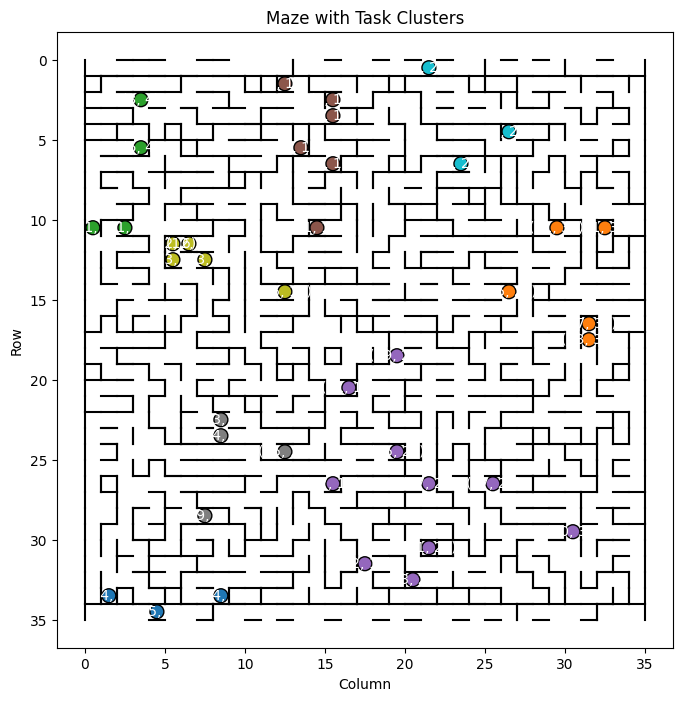

In [8]:
draw_maze_and_tasks("data/maze.csv", num_tasks=40, num_patrols=8)


## Range

In [17]:
df = pd.read_csv("runs/debugging_range/debugging_range_6_40.csv")
df_1 = pd.read_csv("runs/debugging_range/debugging_range_bms_6_40.csv")
df.head()

,num_evs,num_tasks,ev_range,timesteps,num_tasks_finished
0,6,40,10,0,0
1,6,40,20,0,0
2,6,40,30,0,0
3,6,40,40,0,0
4,6,40,50,0,0


In [33]:
df[df["num_tasks_finished"] == 38]

,num_evs,num_tasks,ev_range,timesteps,num_tasks_finished
269,6,40,2700,99,38
270,6,40,2710,99,38
271,6,40,2720,99,38
272,6,40,2730,99,38
273,6,40,2740,99,38
274,6,40,2750,99,38
275,6,40,2760,99,38
276,6,40,2770,99,38
277,6,40,2780,99,38
278,6,40,2790,99,38


In [34]:
df.tail()

,num_evs,num_tasks,ev_range,timesteps,num_tasks_finished
295,6,40,2960,99,38
296,6,40,2970,99,38
297,6,40,2980,99,38
298,6,40,2990,99,38
299,6,40,3000,99,38


In [39]:
df = df[-50:]

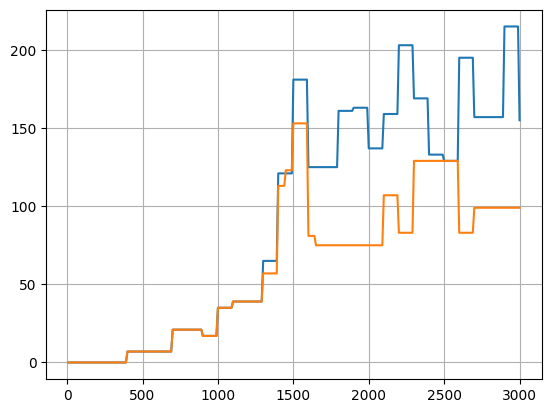

In [19]:
plt.plot(df["ev_range"], df["timesteps"])
plt.plot(df_1["ev_range"], df_1["timesteps"])
plt.grid(True)
plt.show()

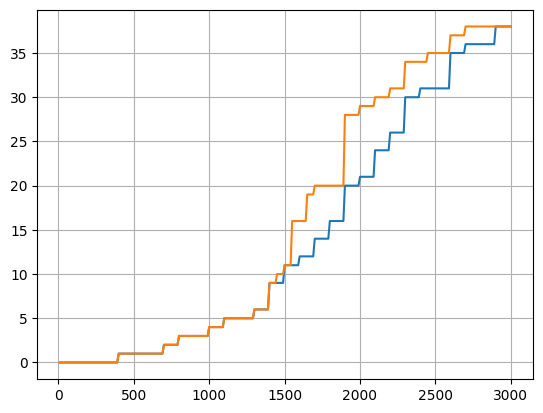

In [18]:
plt.plot(df["ev_range"], df["num_tasks_finished"])
plt.plot(df_1["ev_range"], df_1["num_tasks_finished"])
plt.grid(True)
plt.show()

## Tasks

In [47]:
df = pd.read_csv("runs/debugging_tasks/debugging_tasks_6_3000.csv")
df_1 = pd.read_csv("runs/debugging_tasks/debugging_tasks_bms_6_3000.csv")
df.head()

,num_evs,num_tasks,ev_range,timesteps,num_tasks_finished
0,6,10,3000,53,9
1,6,11,3000,53,10
2,6,12,3000,59,11
3,6,13,3000,59,12
4,6,14,3000,59,12


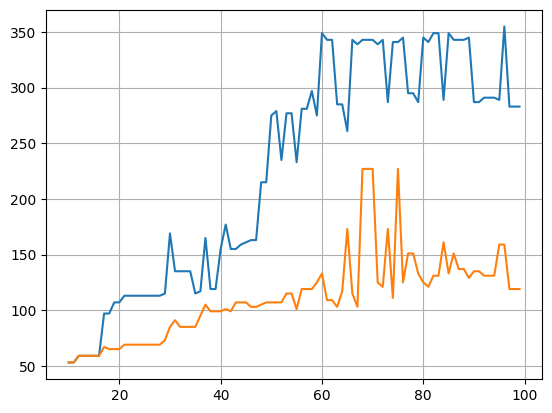

In [48]:
plt.plot(df["num_tasks"], df["timesteps"])
plt.plot(df_1["num_tasks"], df_1["timesteps"])
plt.grid(True)
plt.show()

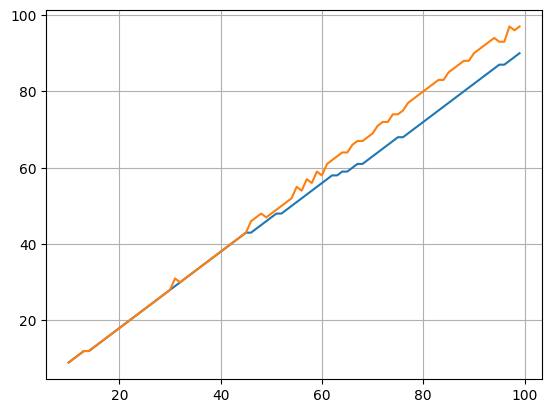

In [49]:
plt.plot(df["num_tasks"], df["num_tasks_finished"])
plt.plot(df_1["num_tasks"], df_1["num_tasks_finished"])
plt.grid(True)
plt.show()

# Streamlined simulations

## Scenario 1

In [51]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("runs/scenario_1/results_2.csv")
# (Optional) Compute an 'energy' column if you also want to plot energy consumption.
df['energy'] = df['ev_distance'] + 0.1*df['drone_distance']
df.head()

,num_evs,num_tasks,ev_range,maze_loop_percentage,maze_size,bms,timesteps,num_tasks_finished,ev_distance,drone_distance,energy
0,9,40,3000,65,35,1,109,37,598.0,584.652473,656.465247
1,9,40,3000,65,37,1,219,36,694.0,468.433166,740.843317
2,9,40,3000,60,43,1,77,25,482.0,507.559026,532.755903
3,9,40,3000,70,40,0,231,30,812.0,0.000000,812.000000
4,9,40,3000,75,41,1,177,31,574.0,586.950302,632.695030


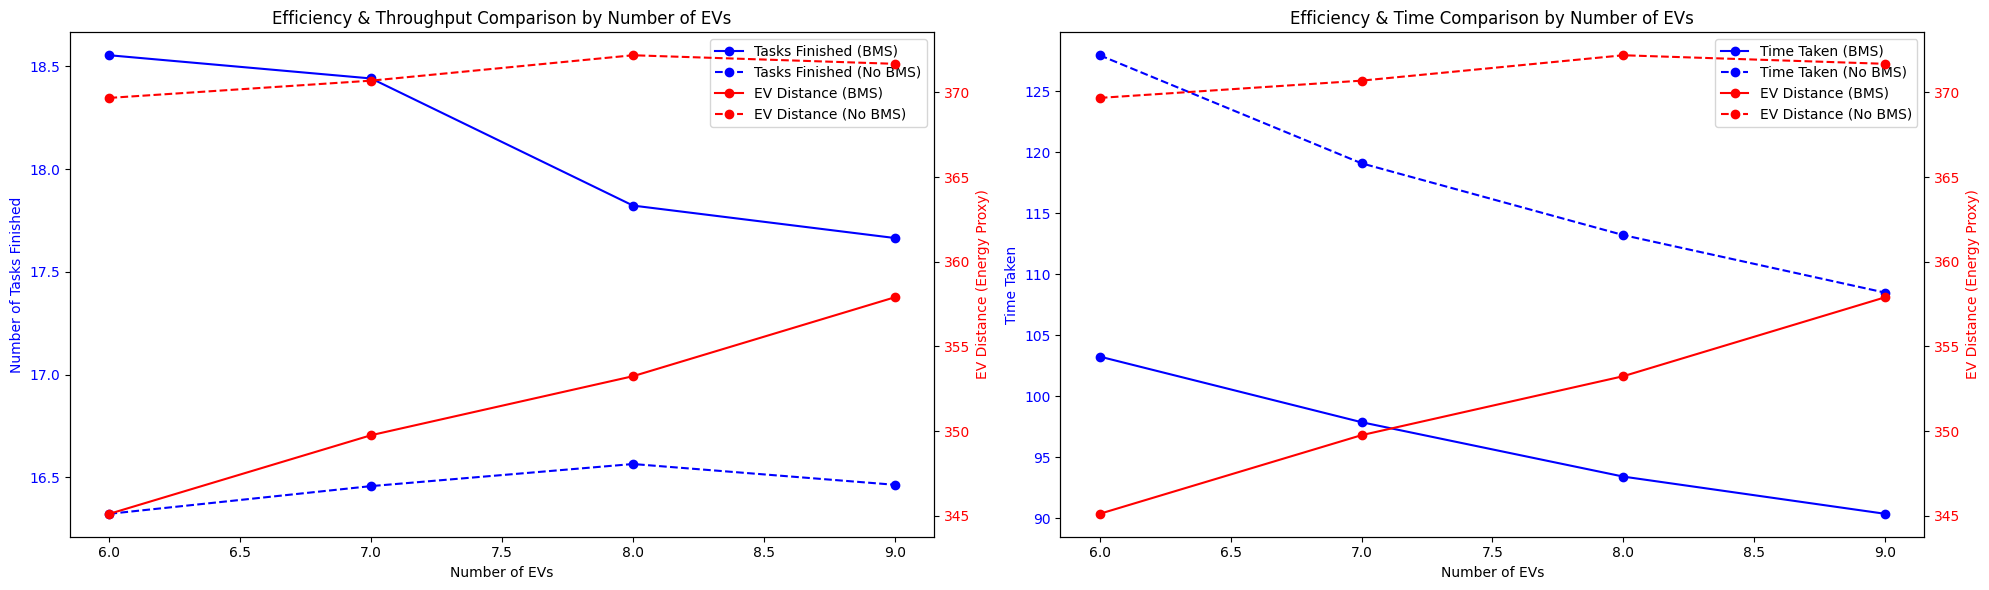

In [21]:
import pandas as pd
import matplotlib.pyplot as plt


# Split the data into BMS and no-BMS cases
df_bms = df[df['bms'] == 1]
df_no_bms = df[df['bms'] == 0]

# Aggregate by number of EVs (here using the mean for each metric)
group_bms = df_bms.groupby('num_evs').mean().reset_index()
group_no_bms = df_no_bms.groupby('num_evs').mean().reset_index()

# Create the dual-axis plot
fig, axs = plt.subplots(1,2,figsize=(20, 6))
ax1 = axs[0]
ax2 = ax1.twinx()

# Plot number of tasks finished on the left y-axis
ax1.plot(group_bms['num_evs'], group_bms['num_tasks_finished'], 'b-o', label='Tasks Finished (BMS)')
ax1.plot(group_no_bms['num_evs'], group_no_bms['num_tasks_finished'], 'b--o', label='Tasks Finished (No BMS)')
ax1.set_xlabel('Number of EVs')
ax1.set_ylabel('Number of Tasks Finished', color='b')
ax1.tick_params(axis='y', labelcolor='b')

# Plot EV distance (as an energy consumption proxy) on the right y-axis
ax2.plot(group_bms['num_evs'], group_bms['energy'], 'r-o', label='EV Distance (BMS)')
ax2.plot(group_no_bms['num_evs'], group_no_bms['energy'], 'r--o', label='EV Distance (No BMS)')
ax2.set_ylabel('EV Distance (Energy Proxy)', color='r')
ax2.tick_params(axis='y', labelcolor='r')

# Combine legends from both axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

plt.title('Efficiency & Throughput Comparison by Number of EVs')
plt.tight_layout()

ax1 = axs[1]
ax2 = ax1.twinx()

# Plot number of tasks finished on the left y-axis
ax1.plot(group_bms['num_evs'], group_bms['timesteps'], 'b-o', label='Time Taken (BMS)')
ax1.plot(group_no_bms['num_evs'], group_no_bms['timesteps'], 'b--o', label='Time Taken (No BMS)')
ax1.set_xlabel('Number of EVs')
ax1.set_ylabel('Time Taken', color='b')
ax1.tick_params(axis='y', labelcolor='b')

# Plot EV distance (as an energy consumption proxy) on the right y-axis
ax2.plot(group_bms['num_evs'], group_bms['energy'], 'r-o', label='EV Distance (BMS)')
ax2.plot(group_no_bms['num_evs'], group_no_bms['energy'], 'r--o', label='EV Distance (No BMS)')
ax2.set_ylabel('EV Distance (Energy Proxy)', color='r')
ax2.tick_params(axis='y', labelcolor='r')

# Combine legends from both axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

plt.title('Efficiency & Time Comparison by Number of EVs')
plt.tight_layout()

plt.show()


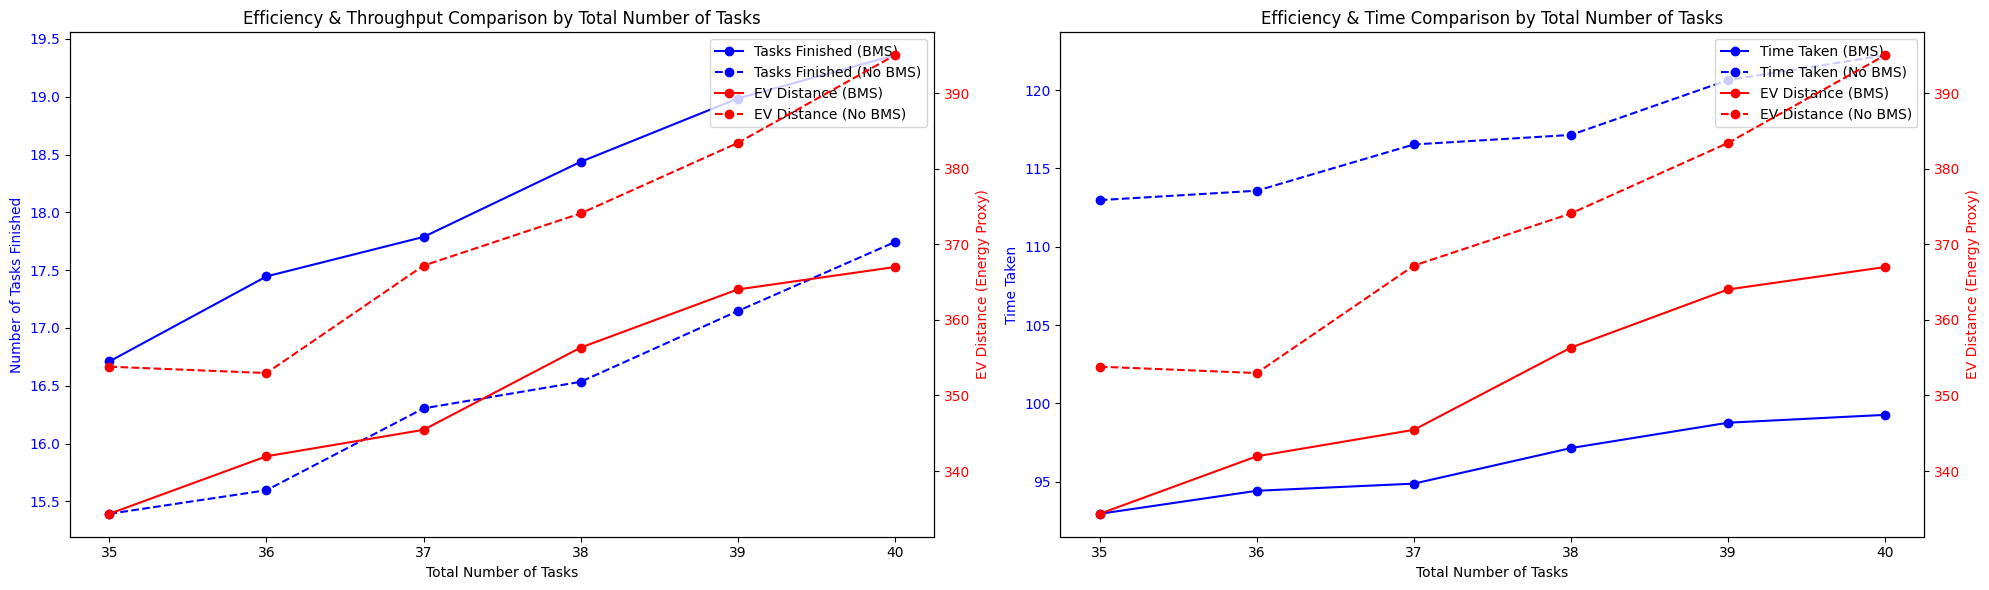

In [22]:
import pandas as pd
import matplotlib.pyplot as plt


# Split the data into BMS and no-BMS cases
df_bms = df[df['bms'] == 1]
df_no_bms = df[df['bms'] == 0]

# Aggregate by number of EVs (here using the mean for each metric)
group_bms = df_bms.groupby('num_tasks').mean().reset_index()
group_no_bms = df_no_bms.groupby('num_tasks').mean().reset_index()

# Create the dual-axis plot
fig, axs = plt.subplots(1,2,figsize=(20, 6))
ax1 = axs[0]
ax2 = ax1.twinx()

# Plot number of tasks finished on the left y-axis
ax1.plot(group_bms['num_tasks'], group_bms['num_tasks_finished'], 'b-o', label='Tasks Finished (BMS)')
ax1.plot(group_no_bms['num_tasks'], group_no_bms['num_tasks_finished'], 'b--o', label='Tasks Finished (No BMS)')
ax1.set_xlabel('Total Number of Tasks')
ax1.set_ylabel('Number of Tasks Finished', color='b')
ax1.tick_params(axis='y', labelcolor='b')

# Plot EV distance (as an energy consumption proxy) on the right y-axis
ax2.plot(group_bms['num_tasks'], group_bms['energy'], 'r-o', label='EV Distance (BMS)')
ax2.plot(group_no_bms['num_tasks'], group_no_bms['energy'], 'r--o', label='EV Distance (No BMS)')
ax2.set_ylabel('EV Distance (Energy Proxy)', color='r')
ax2.tick_params(axis='y', labelcolor='r')

# Combine legends from both axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

plt.title('Efficiency & Throughput Comparison by Total Number of Tasks')
plt.tight_layout()

ax1 = axs[1]
ax2 = ax1.twinx()

# Plot number of tasks finished on the left y-axis
ax1.plot(group_bms['num_tasks'], group_bms['timesteps'], 'b-o', label='Time Taken (BMS)')
ax1.plot(group_no_bms['num_tasks'], group_no_bms['timesteps'], 'b--o', label='Time Taken (No BMS)')
ax1.set_xlabel('Total Number of Tasks')
ax1.set_ylabel('Time Taken', color='b')
ax1.tick_params(axis='y', labelcolor='b')

# Plot EV distance (as an energy consumption proxy) on the right y-axis
ax2.plot(group_bms['num_tasks'], group_bms['energy'], 'r-o', label='EV Distance (BMS)')
ax2.plot(group_no_bms['num_tasks'], group_no_bms['energy'], 'r--o', label='EV Distance (No BMS)')
ax2.set_ylabel('EV Distance (Energy Proxy)', color='r')
ax2.tick_params(axis='y', labelcolor='r')

# Combine legends from both axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

plt.title('Efficiency & Time Comparison by Total Number of Tasks')
plt.tight_layout()

plt.show()


In [28]:
# import pandas as pd
# import matplotlib.pyplot as plt


# # Split the data into BMS and no-BMS cases
# df_bms = df[df['bms'] == 1]
# df_no_bms = df[df['bms'] == 0]

# # Aggregate by number of EVs (here using the mean for each metric)
# group_bms = df_bms.groupby('ev_range').mean().reset_index()
# group_no_bms = df_no_bms.groupby('ev_range').mean().reset_index()

# # Create the dual-axis plot
# fig, axs = plt.subplots(1,2,figsize=(20, 6))
# ax1 = axs[0]
# ax2 = ax1.twinx()

# # Plot number of tasks finished on the left y-axis
# ax1.plot(group_bms['ev_range'], group_bms['num_tasks_finished'], 'b-o', label='Tasks Finished (BMS)')
# ax1.plot(group_no_bms['ev_range'], group_no_bms['num_tasks_finished'], 'b--o', label='Tasks Finished (No BMS)')
# ax1.set_xlabel('EV Range')
# ax1.set_ylabel('Number of Tasks Finished', color='b')
# ax1.tick_params(axis='y', labelcolor='b')

# # Plot EV distance (as an energy consumption proxy) on the right y-axis
# ax2.plot(group_bms['ev_range'], group_bms['energy'], 'r-o', label='EV Distance (BMS)')
# ax2.plot(group_no_bms['ev_range'], group_no_bms['energy'], 'r--o', label='EV Distance (No BMS)')
# ax2.set_ylabel('EV Distance (Energy Proxy)', color='r')
# ax2.tick_params(axis='y', labelcolor='r')

# # Combine legends from both axes
# lines_1, labels_1 = ax1.get_legend_handles_labels()
# lines_2, labels_2 = ax2.get_legend_handles_labels()
# ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

# plt.title('Efficiency & Throughput Comparison by EV Range')
# plt.tight_layout()

# ax1 = axs[1]
# ax2 = ax1.twinx()

# # Plot number of tasks finished on the left y-axis
# ax1.plot(group_bms['ev_range'], group_bms['timesteps'], 'b-o', label='Time Taken (BMS)')
# ax1.plot(group_no_bms['num_tasks'], group_no_bms['timesteps'], 'b--o', label='Time Taken (No BMS)')
# ax1.set_xlabel('EV Range')
# ax1.set_ylabel('Time Taken', color='b')
# ax1.tick_params(axis='y', labelcolor='b')

# # Plot EV distance (as an energy consumption proxy) on the right y-axis
# ax2.plot(group_bms['ev_range'], group_bms['energy'], 'r-o', label='EV Distance (BMS)')
# ax2.plot(group_no_bms['ev_range'], group_no_bms['energy'], 'r--o', label='EV Distance (No BMS)')
# ax2.set_ylabel('EV Distance (Energy Proxy)', color='r')
# ax2.tick_params(axis='y', labelcolor='r')

# # Combine legends from both axes
# lines_1, labels_1 = ax1.get_legend_handles_labels()
# lines_2, labels_2 = ax2.get_legend_handles_labels()
# ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

# plt.title('Efficiency & Time Comparison by EV Range')
# plt.tight_layout()

# plt.show()


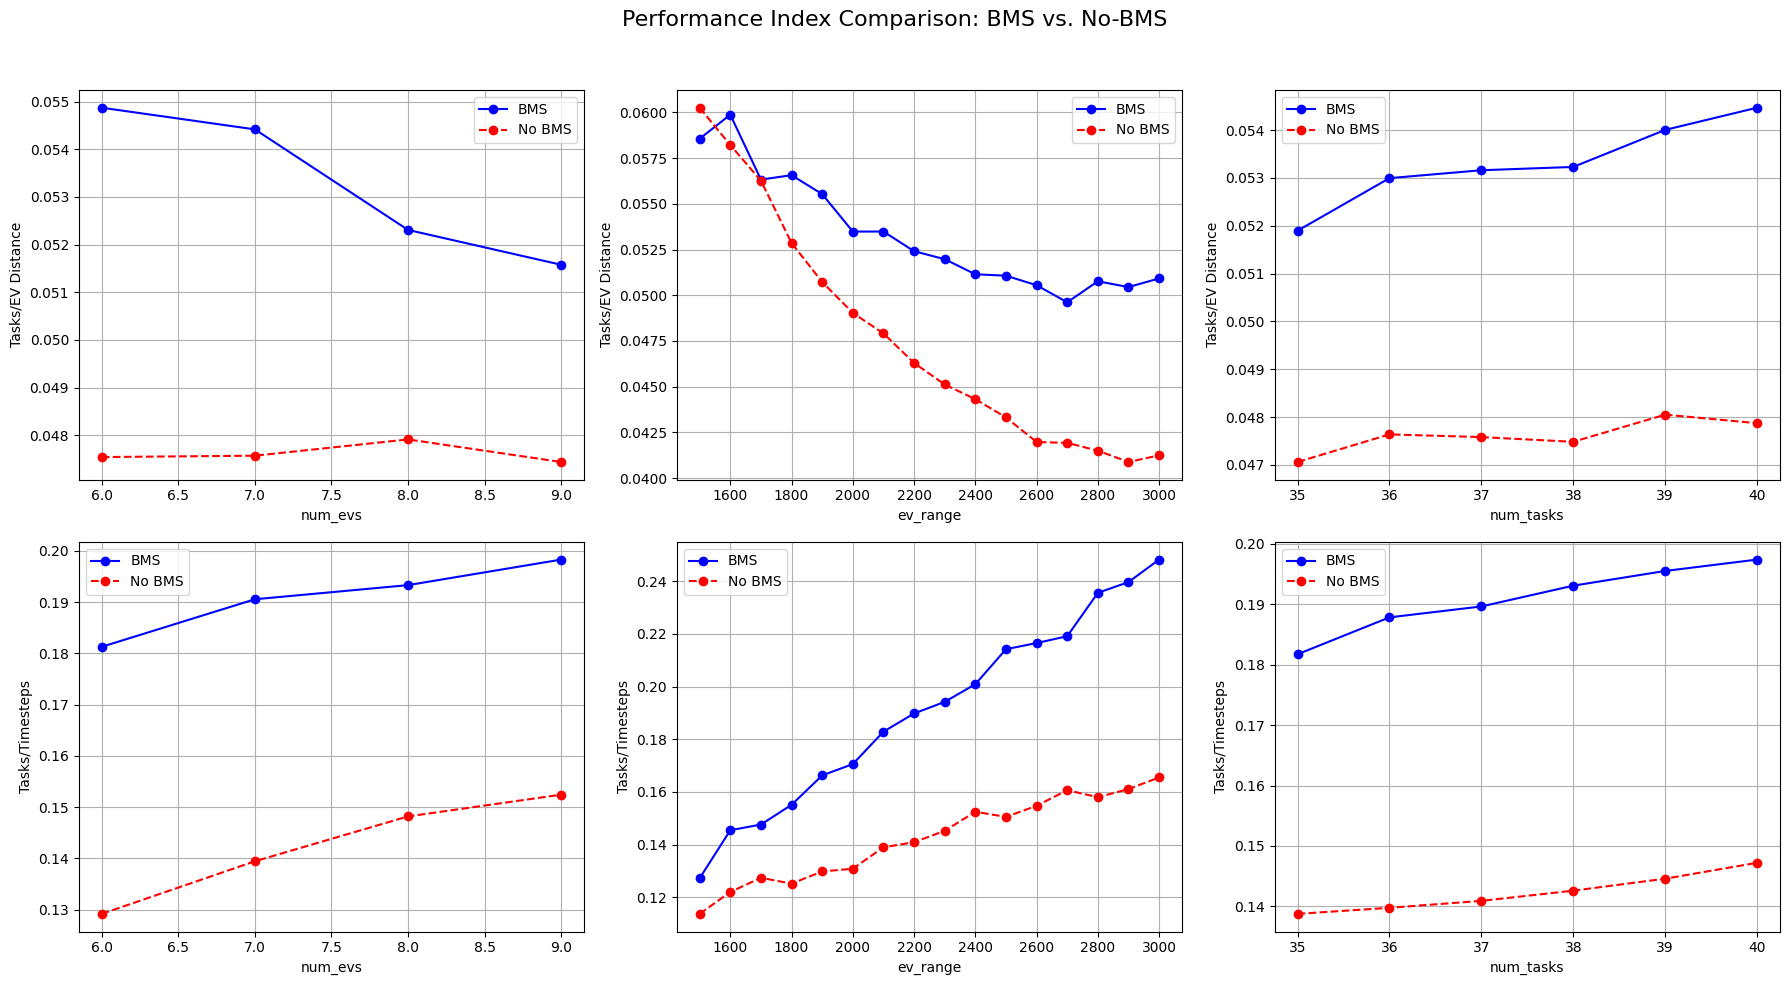

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# Compute performance indexes for each row
df['pi_energy'] = df['num_tasks_finished'] / df['energy']
df['pi_time'] = df['num_tasks_finished'] / df['timesteps']

# Define a function to plot performance index vs a parameter
def plot_performance(ax, param, metric, metric_label):
    # Split the data for BMS and no-BMS
    df_bms = df[df['bms'] == 1]
    df_no_bms = df[df['bms'] == 0]
    
    # Group by the parameter and calculate the mean performance index
    group_bms = df_bms.groupby(param)[metric].mean().reset_index()
    group_no_bms = df_no_bms.groupby(param)[metric].mean().reset_index()
    
    # Plot the curves
    ax.plot(group_bms[param], group_bms[metric], 'bo-', label='BMS')
    ax.plot(group_no_bms[param], group_no_bms[metric], 'ro--', label='No BMS')
    
    ax.set_xlabel(param)
    ax.set_ylabel(metric_label)
    ax.legend()
    ax.grid(True)

# Set up the subplots: 2 rows (one for each performance index) x 3 columns (one for each parameter)
fig, axs = plt.subplots(2, 3, figsize=(18, 10))

# List of parameters to plot along x-axis
parameters = ['num_evs', 'ev_range', 'num_tasks']

# Plot PI_energy (tasks/energy) on the top row
for i, param in enumerate(parameters):
    plot_performance(axs[0, i], param, 'pi_energy', 'Tasks/EV Distance')

# Plot PI_time (tasks/timesteps) on the bottom row
for i, param in enumerate(parameters):
    plot_performance(axs[1, i], param, 'pi_time', 'Tasks/Timesteps')

fig.suptitle('Performance Index Comparison: BMS vs. No-BMS', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


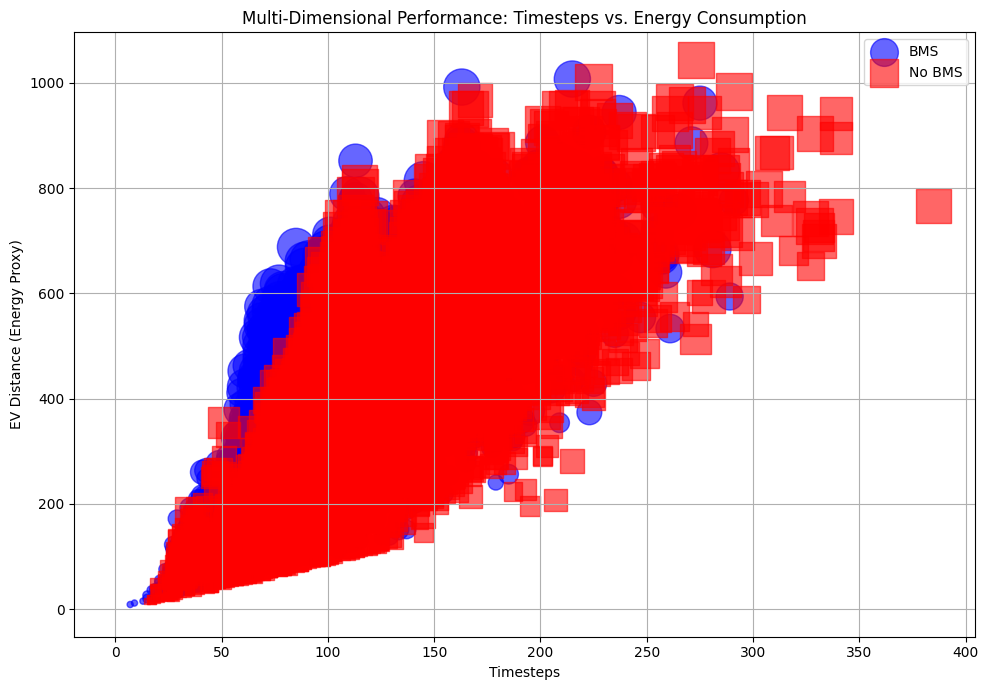

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# Split the data into BMS and no-BMS cases
df_bms = df[df['bms'] == 1]
df_no_bms = df[df['bms'] == 0]

# Create the bubble chart
plt.figure(figsize=(10, 7))

# For BMS: Use a marker style and color, and scale bubble sizes by num_tasks_finished
plt.scatter(df_bms['timesteps'], df_bms['energy'],
            s=df_bms['num_tasks_finished']*20,  # Scale factor for bubble sizes
            alpha=0.6, c='blue', marker='o', label='BMS')

# For no-BMS: Use a different marker style and color
plt.scatter(df_no_bms['timesteps'], df_no_bms['energy'],
            s=df_no_bms['num_tasks_finished']*20,
            alpha=0.6, c='red', marker='s', label='No BMS')

plt.xlabel("Timesteps")
plt.ylabel("EV Distance (Energy Proxy)")
plt.title("Multi-Dimensional Performance: Timesteps vs. Energy Consumption")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


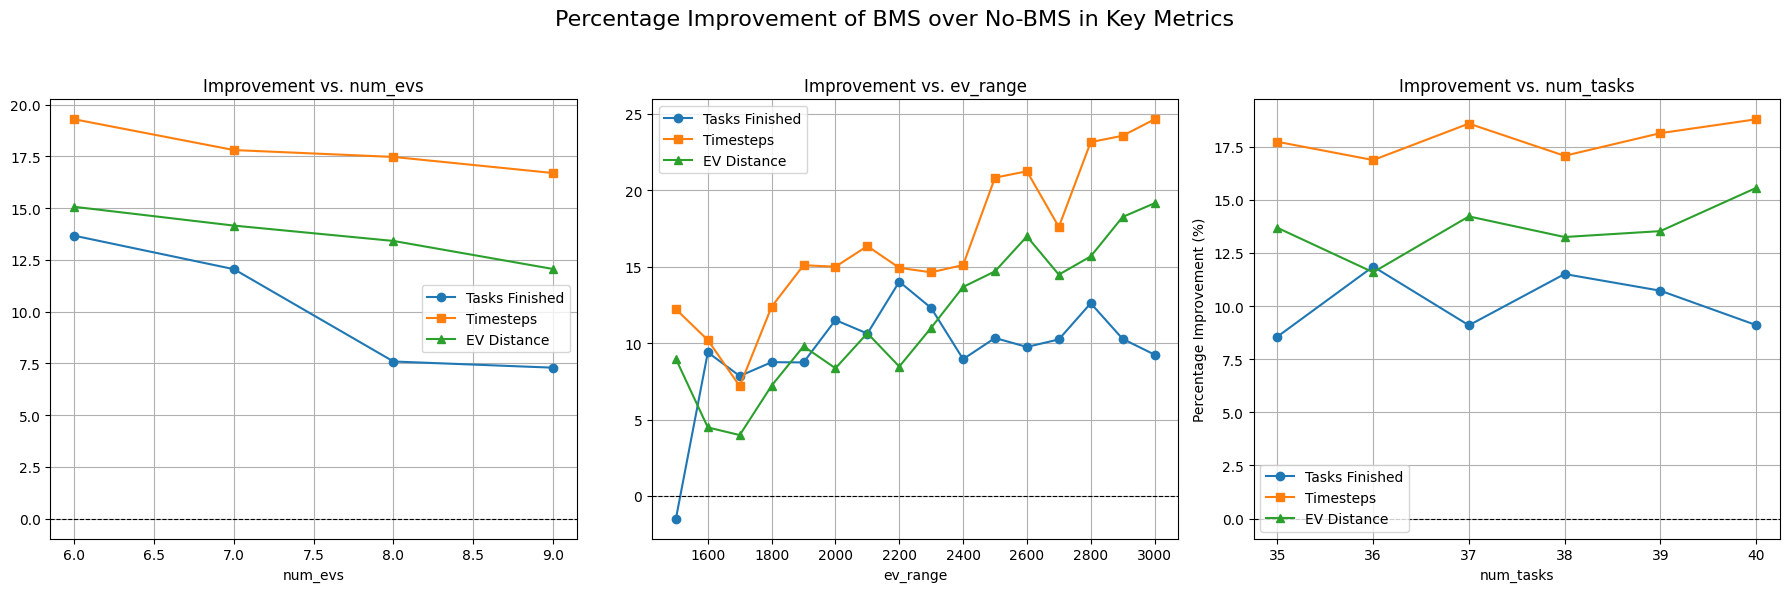

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# Define the parameters to group by
parameters = ['num_evs', 'ev_range', 'num_tasks']

# Create a figure with one subplot per parameter
fig, axs = plt.subplots(1, len(parameters), figsize=(18, 6), sharey=False)

# Loop over each parameter to compute and plot the percentage improvement
for ax, param in zip(axs, parameters):
    # Separate the data into BMS and no-BMS cases and group by the current parameter
    bms_group = df[df['bms'] == 1].groupby(param).mean().reset_index()
    nobms_group = df[df['bms'] == 0].groupby(param).mean().reset_index()
    
    # Merge the grouped data on the parameter values
    merged = pd.merge(bms_group, nobms_group, on=param, suffixes=('_bms', '_nobms'))
    
    # Compute percentage improvements:
    # For tasks finished (higher is better):
    merged['tasks_improve'] = (merged['num_tasks_finished_bms'] - merged['num_tasks_finished_nobms']) / merged['num_tasks_finished_nobms'] * 100
    # For timesteps (lower is better):
    merged['timesteps_improve'] = (merged['timesteps_nobms'] - merged['timesteps_bms']) / merged['timesteps_nobms'] * 100
    # For EV distance (lower is better):
    merged['ev_distance_improve'] = (merged['ev_distance_nobms'] - merged['ev_distance_bms']) / merged['ev_distance_nobms'] * 100

    # Plot the percentage improvements for each metric
    ax.plot(merged[param], merged['tasks_improve'], marker='o', label='Tasks Finished')
    ax.plot(merged[param], merged['timesteps_improve'], marker='s', label='Timesteps')
    ax.plot(merged[param], merged['ev_distance_improve'], marker='^', label='EV Distance')
    
    ax.set_xlabel(param)
    ax.set_title(f"Improvement vs. {param}")
    ax.grid(True)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.legend()

plt.ylabel("Percentage Improvement (%)")
plt.suptitle("Percentage Improvement of BMS over No-BMS in Key Metrics", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


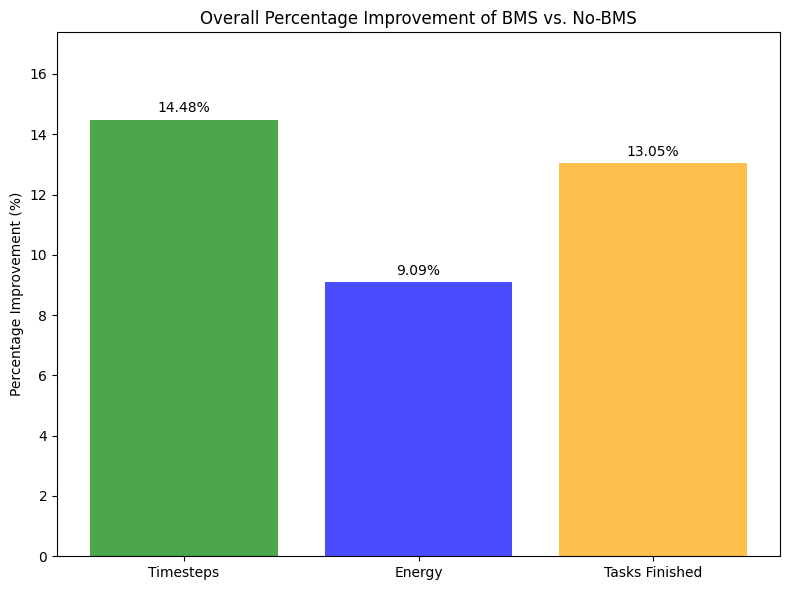

In [54]:
import pandas as pd
import matplotlib.pyplot as plt


# Split the data into BMS (bms == 1) and no-BMS (bms == 0)
df_bms = df[df['bms'] == 1]
df_no_bms = df[df['bms'] == 0]

# Compute overall average metrics for each group
avg_timesteps_bms = df_bms['timesteps'].mean()
avg_timesteps_no_bms = df_no_bms['timesteps'].mean()

avg_energy_bms = df_bms['energy'].mean()  # using energy as energy proxy
avg_energy_no_bms = df_no_bms['energy'].mean()

avg_tasks_bms = df_bms['num_tasks_finished'].mean()
avg_tasks_no_bms = df_no_bms['num_tasks_finished'].mean()

# Calculate percentage improvements:
# For timesteps and energy, a reduction is an improvement:
pi_timesteps = ((avg_timesteps_no_bms - avg_timesteps_bms) / avg_timesteps_no_bms) * 100
pi_energy = ((avg_energy_no_bms - avg_energy_bms) / avg_energy_no_bms) * 100
# For tasks finished, an increase is an improvement:
pi_tasks = ((avg_tasks_bms - avg_tasks_no_bms) / avg_tasks_no_bms) * 100

# Prepare data for plotting
metrics = ['Timesteps', 'Energy', 'Tasks Finished']
pi_values = [pi_timesteps, pi_energy, pi_tasks]

# Create a bar plot
plt.figure(figsize=(8, 6))
bars = plt.bar(metrics, pi_values, color=['green', 'blue', 'orange'], alpha=0.7)
plt.ylabel('Percentage Improvement (%)')
plt.title('Overall Percentage Improvement of BMS vs. No-BMS')

# Annotate each bar with its value
for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{height:.2f}%',
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3),  # vertical offset
                 textcoords="offset points",
                 ha='center', va='bottom')

plt.ylim(0, max(pi_values) * 1.2)
plt.tight_layout()
plt.show()


## Scenario 1 new

In [53]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("runs/scenario_2/results_ev.csv")
# (Optional) Compute an 'energy' column if you also want to plot energy consumption.
df['energy'] = df['ev_distance'] + 0.01*df['drone_distance']
df.head()

,num_evs,num_tasks,ev_range,maze_loop_percentage,maze_size,bms,timesteps,num_tasks_finished,ev_distance,drone_distance,energy
0,10,25,1700,90,35,0,83,10,178.0,0.000000,178.000000
1,10,34,2600,90,36,1,93,24,430.0,283.704231,432.837042
2,10,28,2800,90,38,1,81,24,416.0,305.295100,419.052951
3,10,26,2800,90,39,0,135,19,508.0,0.000000,508.000000
4,10,28,2400,90,46,1,89,13,296.0,241.673820,298.416738


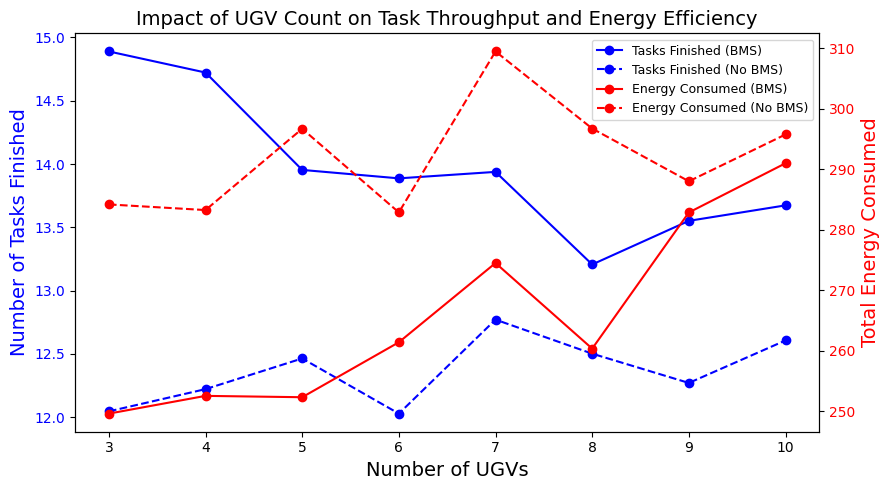

In [38]:
import pandas as pd
import matplotlib.pyplot as plt


# Split the data into BMS and no-BMS cases
df_bms = df[df['bms'] == 1]
df_no_bms = df[df['bms'] == 0]

# Aggregate by number of EVs (here using the mean for each metric)
group_bms = df_bms.groupby('num_evs').mean().reset_index()
group_no_bms = df_no_bms.groupby('num_evs').mean().reset_index()

# Create the dual-axis plot
fig, axs = plt.subplots(figsize=(9, 5))
ax1 = axs
ax2 = axs.twinx()

# Plot number of tasks finished on the left y-axis
ax1.plot(group_bms['num_evs'], group_bms['num_tasks_finished'], 'b-o', label='Tasks Finished (BMS)')
ax1.plot(group_no_bms['num_evs'], group_no_bms['num_tasks_finished'], 'b--o', label='Tasks Finished (No BMS)')
ax1.set_xlabel('Number of UGVs', fontsize=14)
ax1.set_ylabel('Number of Tasks Finished', color='b', fontsize=14)
ax1.tick_params(axis='y', labelcolor='b')

# Plot EV distance (as an energy consumption proxy) on the right y-axis
ax2.plot(group_bms['num_evs'], group_bms['energy'], 'r-o', label='Energy Consumed (BMS)')
ax2.plot(group_no_bms['num_evs'], group_no_bms['energy'], 'r--o', label='Energy Consumed (No BMS)')
ax2.set_ylabel('Total Energy Consumed', color='r', fontsize=14)
ax2.tick_params(axis='y', labelcolor='r')

# Combine legends from both axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right', fontsize=9)

plt.title('Impact of UGV Count on Task Throughput and Energy Efficiency', fontsize=14)
plt.tight_layout()

plt.show()


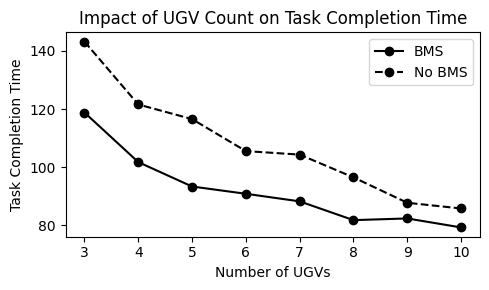

In [39]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df is already defined

param = 'num_evs'
metric = 'timesteps'

# Group the DataFrame by 'bms' and the chosen parameter, taking the average of the selected metric
grouped = df.groupby(['bms', param], as_index=False)[metric].mean()

# Split into BMS (1) and No BMS (0) cases
df_yes_bms = grouped[grouped['bms'] == 1]
df_no_bms = grouped[grouped['bms'] == 0]

# Create a figure and axis similar to the first plot
fig, ax = plt.subplots(figsize=(5, 3))

# Plot BMS (solid blue with circle markers) and No BMS (dashed blue with circle markers)
ax.plot(df_yes_bms[param], df_yes_bms[metric], 'k-o', label='BMS')
ax.plot(df_no_bms[param], df_no_bms[metric], 'k--o', label='No BMS')

# Label the axes and add a title
ax.set_xlabel('Number of UGVs')
ax.set_ylabel('Task Completion Time', color='k')
ax.tick_params(axis='y', labelcolor='k')
ax.set_title('Impact of UGV Count on Task Completion Time')

# Place the legend in the upper right, similar to the first plot
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()


## Scenario 2 new

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("runs/scenario_2/results_tasks.csv")
# (Optional) Compute an 'energy' column if you also want to plot energy consumption.
df['energy'] = df['ev_distance'] + 0.01*df['drone_distance']
df.head()

,num_evs,num_tasks,ev_range,maze_loop_percentage,maze_size,bms,timesteps,num_tasks_finished,ev_distance,drone_distance,energy
0,7,40,2300,90,37,1,135,33,536.0,593.837507,541.938375
1,3,40,2400,90,39,1,209,27,538.0,499.938027,542.999380
2,8,40,1600,90,37,1,81,14,274.0,200.897423,276.008974
3,9,40,1800,90,38,0,69,12,190.0,0.000000,190.000000
4,6,40,2800,90,44,1,105,32,390.0,588.581634,395.885816


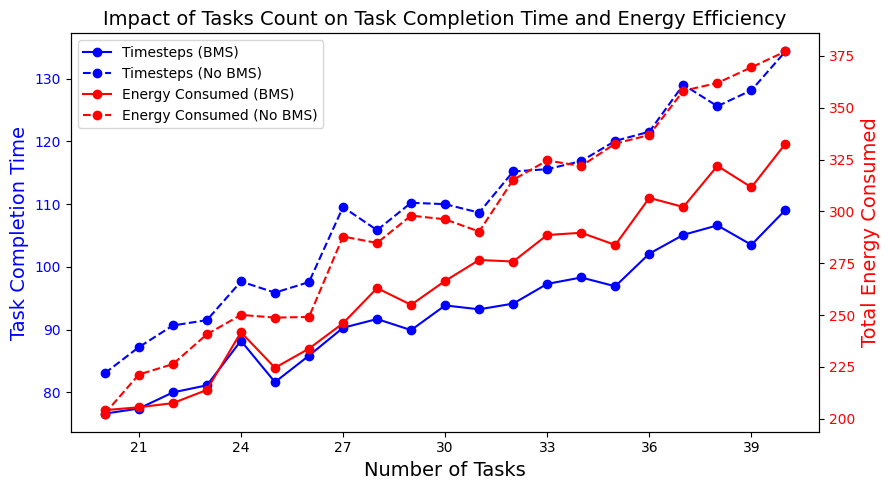

In [47]:
# import pandas as pd
# import matplotlib.pyplot as plt


# # Split the data into BMS and no-BMS cases
# df_bms = df[df['bms'] == 1]
# df_no_bms = df[df['bms'] == 0]

# # Aggregate by number of EVs (here using the mean for each metric)
# group_bms = df_bms.groupby('num_tasks').mean().reset_index()
# group_no_bms = df_no_bms.groupby('num_tasks').mean().reset_index()

# # Create the dual-axis plot
# fig, axs = plt.subplots(figsize=(9, 5))
# ax1 = axs
# ax2 = axs.twinx()

# # Plot number of tasks finished on the left y-axis
# ax1.plot(group_bms['num_tasks'], group_bms['timesteps'], 'b-o', label='Timesteps (BMS)')
# ax1.plot(group_no_bms['num_tasks'], group_no_bms['timesteps'], 'b--o', label='Timesteps (No BMS)')
# ax1.set_xlabel('Number of Tasks', fontsize=14)
# ax1.set_ylabel('Task Completion Time', color='b', fontsize=14)
# ax1.tick_params(axis='y', labelcolor='b')

# # Plot EV distance (as an energy consumption proxy) on the right y-axis
# ax2.plot(group_bms['num_tasks'], group_bms['energy'], 'r-o', label='Energy Consumed (BMS)')
# ax2.plot(group_no_bms['num_tasks'], group_no_bms['energy'], 'r--o', label='Energy Consumed (No BMS)')
# ax2.set_ylabel('Total Energy Consumed', color='r', fontsize=14)
# ax2.tick_params(axis='y', labelcolor='r')

# # Set x-axis ticks to integers
# ax1.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# # Combine legends from both axes
# lines_1, labels_1 = ax1.get_legend_handles_labels()
# lines_2, labels_2 = ax2.get_legend_handles_labels()
# ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

# plt.title('Impact of Tasks Count on Task Completion Time and Energy Efficiency', fontsize=14)
# plt.tight_layout()

# plt.show()

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Assuming your DataFrame 'df' is already loaded

# Split the data into BMS and no-BMS cases
df_bms = df[df['bms'] == 1]
df_no_bms = df[df['bms'] == 0]

# Aggregate by number of EVs (here using the mean for each metric)
group_bms = df_bms.groupby('num_tasks').mean().reset_index()
group_no_bms = df_no_bms.groupby('num_tasks').mean().reset_index()

# Create the dual-axis plot
fig, axs = plt.subplots(figsize=(9, 5))
ax1 = axs
ax2 = axs.twinx()

# Plot number of tasks finished on the left y-axis
ax1.plot(group_bms['num_tasks'], group_bms['timesteps'], 'b-o', label='Timesteps (BMS)')
ax1.plot(group_no_bms['num_tasks'], group_no_bms['timesteps'], 'b--o', label='Timesteps (No BMS)')
ax1.set_xlabel('Number of Tasks', fontsize=14)
ax1.set_ylabel('Task Completion Time', color='b', fontsize=14)
ax1.tick_params(axis='y', labelcolor='b')

# Plot EV distance (as an energy consumption proxy) on the right y-axis
ax2.plot(group_bms['num_tasks'], group_bms['energy'], 'r-o', label='Energy Consumed (BMS)')
ax2.plot(group_no_bms['num_tasks'], group_no_bms['energy'], 'r--o', label='Energy Consumed (No BMS)')
ax2.set_ylabel('Total Energy Consumed', color='r', fontsize=14)
ax2.tick_params(axis='y', labelcolor='r')

# Set x-axis ticks to integers
ax1.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# Combine legends from both axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

plt.title('Impact of Tasks Count on Task Completion Time and Energy Efficiency', fontsize=14)
plt.tight_layout()

plt.show()

## Scenario 3 new

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("runs/scenario_2/results_ev.csv")
# (Optional) Compute an 'energy' column if you also want to plot energy consumption.
df['energy'] = df['ev_distance'] + 0.01*df['drone_distance']
df.head()

,num_evs,num_tasks,ev_range,maze_loop_percentage,maze_size,bms,timesteps,num_tasks_finished,ev_distance,drone_distance,energy
0,10,25,1700,90,35,0,83,10,178.0,0.000000,178.000000
1,10,34,2600,90,36,1,93,24,430.0,283.704231,432.837042
2,10,28,2800,90,38,1,81,24,416.0,305.295100,419.052951
3,10,26,2800,90,39,0,135,19,508.0,0.000000,508.000000
4,10,28,2400,90,46,1,89,13,296.0,241.673820,298.416738


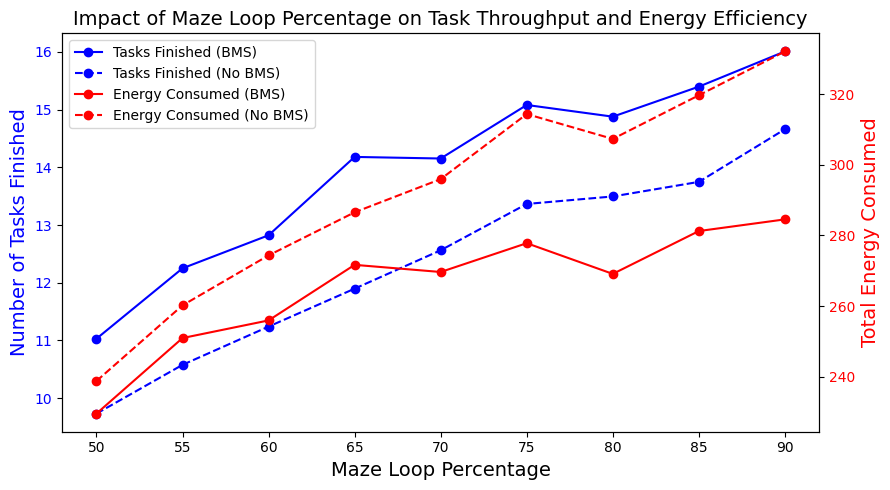

In [49]:
import pandas as pd
import matplotlib.pyplot as plt


# Split the data into BMS and no-BMS cases
df_bms = df[df['bms'] == 1]
df_no_bms = df[df['bms'] == 0]

# Aggregate by number of EVs (here using the mean for each metric)
group_bms = df_bms.groupby('maze_loop_percentage').mean().reset_index()
group_no_bms = df_no_bms.groupby('maze_loop_percentage').mean().reset_index()

# Create the dual-axis plot
fig, axs = plt.subplots(figsize=(9,5))
ax1 = axs
ax2 = axs.twinx()

# Plot number of tasks finished on the left y-axis
ax1.plot(group_bms['maze_loop_percentage'], group_bms['num_tasks_finished'], 'b-o', label='Tasks Finished (BMS)')
ax1.plot(group_no_bms['maze_loop_percentage'], group_no_bms['num_tasks_finished'], 'b--o', label='Tasks Finished (No BMS)')
ax1.set_xlabel('Maze Loop Percentage', fontsize=14)
ax1.set_ylabel('Number of Tasks Finished', color='b', fontsize=14)
ax1.tick_params(axis='y', labelcolor='b')

# Plot EV distance (as an energy consumption proxy) on the right y-axis
ax2.plot(group_bms['maze_loop_percentage'], group_bms['energy'], 'r-o', label='Energy Consumed (BMS)')
ax2.plot(group_no_bms['maze_loop_percentage'], group_no_bms['energy'], 'r--o', label='Energy Consumed (No BMS)')
ax2.set_ylabel('Total Energy Consumed', color='r', fontsize=14)
ax2.tick_params(axis='y', labelcolor='r')

# Combine legends from both axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

plt.title('Impact of Maze Loop Percentage on Task Throughput and Energy Efficiency', fontsize=14)
plt.tight_layout()

plt.show()


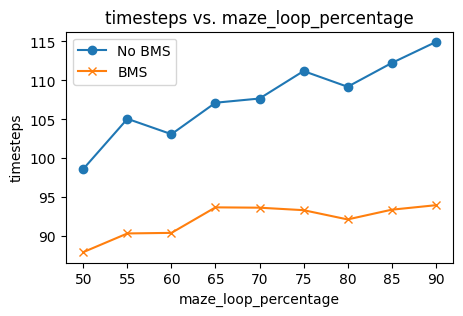

In [35]:
param = 'maze_loop_percentage'
metric = 'timesteps'

# Group the DataFrame by 'bms' and the chosen parameter, and take the average of the selected metric
grouped = df.groupby(['bms', param], as_index=False)[metric].mean()

# Split into No BMS (0) and BMS (1)
df_no_bms = grouped[grouped['bms'] == 0]
df_yes_bms = grouped[grouped['bms'] == 1]

# 4. Create a figure for each plot
plt.figure(figsize=(5,3))

# Plot No BMS line
plt.plot(df_no_bms[param], df_no_bms[metric], marker='o', label='No BMS')

# Plot BMS line
plt.plot(df_yes_bms[param], df_yes_bms[metric], marker='x', label='BMS')

# 5. Label the axes and add a title/legend
plt.xlabel(param)
plt.ylabel(metric)
plt.title(f'{metric} vs. {param}')
plt.legend()

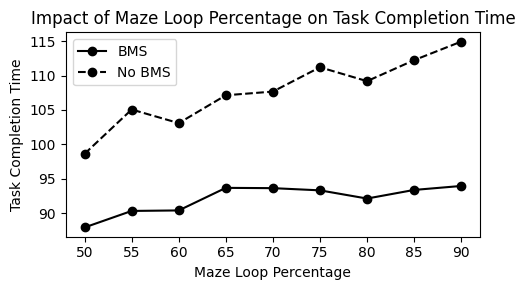

In [50]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df is already defined

param = 'maze_loop_percentage'
metric = 'timesteps'

# Group the DataFrame by 'bms' and the chosen parameter, taking the average of the selected metric
grouped = df.groupby(['bms', param], as_index=False)[metric].mean()

# Split into BMS (1) and No BMS (0) cases
df_yes_bms = grouped[grouped['bms'] == 1]
df_no_bms = grouped[grouped['bms'] == 0]

# Create a figure and axis similar to the first plot
fig, ax = plt.subplots(figsize=(5,3))

# Plot BMS (solid blue with circle markers) and No BMS (dashed blue with circle markers)
ax.plot(df_yes_bms[param], df_yes_bms[metric], 'k-o', label='BMS')
ax.plot(df_no_bms[param], df_no_bms[metric], 'k--o', label='No BMS')

# Label the axes and add a title
ax.set_xlabel('Maze Loop Percentage')
ax.set_ylabel('Task Completion Time', color='k')
ax.tick_params(axis='y', labelcolor='k')
ax.set_title('Impact of Maze Loop Percentage on Task Completion Time')

# Place the legend in the upper right, similar to the first plot
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()
